In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.datasets import load_iris

In [2]:
RF = RandomForestClassifier(n_estimators=100, n_jobs=4, oob_score=True)
iris = load_iris()
x = iris.data[:, :2]
y = iris.target
RF.fit(x, y)
h = .02

In [3]:
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

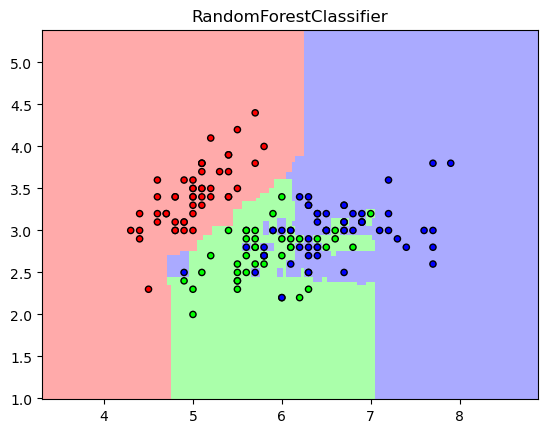

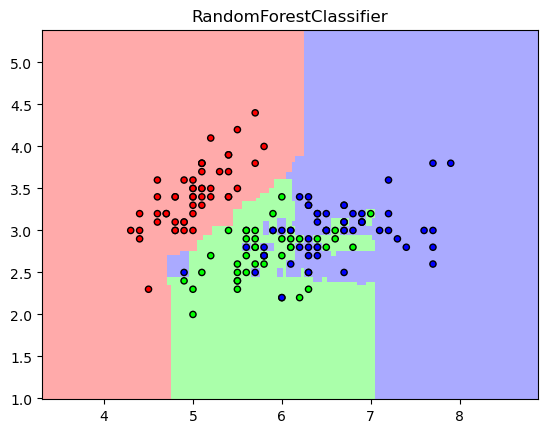

In [4]:
for weight in ['uniform', 'distance']:
    x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
    y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    z = RF.predict(np.c_[xx.ravel(), yy.ravel()])
    z = z.reshape(xx.shape)
    plt.figure()
    plt.pcolormesh(xx, yy, z, cmap=cmap_light)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap_bold, edgecolors='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.title('RandomForestClassifier')

In [5]:
plt.show()
print('RandomForestClassifier:', RF.score(x, y))

RandomForestClassifier: 0.9266666666666666
